In [1]:
# ============================================================
# CELL 1: Imports, mount Drive, load data
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# >>> EDIT THIS PATH to wherever the file sits in your Drive <
PATH = '/content/drive/MyDrive/Colab Notebooks/covid_symptoms_severity_prediction.csv'

df = pd.read_csv(PATH)

print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nFirst 5 rows:')
display(df.head())
print('\nInfo:')
df.info()

Mounted at /content/drive
Shape: (3000, 17)

Columns: ['age', 'gender', 'vaccination_status', 'fever', 'cough', 'fatigue', 'shortness_of_breath', 'loss_of_smell', 'headache', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'cancer', 'hospitalized', 'icu_admission', 'mortality']

First 5 rows:


,age,gender,vaccination_status,fever,cough,fatigue,shortness_of_breath,loss_of_smell,headache,diabetes,hypertension,heart_disease,asthma,cancer,hospitalized,icu_admission,mortality
0,51,Male,Unvaccinated,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,92,Male,Fully Vaccinated,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,14,Male,Fully Vaccinated,0,1,0,0,0,0,0,0,0,0,1,0,0,0
3,71,Male,Fully Vaccinated,1,1,0,0,0,0,0,1,0,0,0,0,0,0
4,60,Male,Unvaccinated,0,1,1,1,1,0,1,1,1,0,0,1,1,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   age                  3000 non-null   int64 
 1   gender               3000 non-null   object
 2   vaccination_status   3000 non-null   object
 3   fever                3000 non-null   int64 
 4   cough                3000 non-null   int64 
 5   fatigue              3000 non-null   int64 
 6   shortness_of_breath  3000 non-null   int64 
 7   loss_of_smell        3000 non-null   int64 
 8   headache             3000 non-null   int64 
 9   diabetes             3000 non-null   int64 
 10  hypertension         3000 non-null   int64 
 11  heart_disease        3000 non-null   int64 
 12  asthma               3000 non-null   int64 
 13  cancer               3000 non-null   int64 
 14  hospitalized         3000 non-null   int64 
 15  icu_admission        3000 non-null   int64 
 16 

In [2]:
# ============================================================
# CELL 2a: Define column groups + basic checks
# ============================================================
TARGET      = 'mortality'
SYMPTOMS    = ['fever', 'cough', 'fatigue',
               'shortness_of_breath', 'loss_of_smell', 'headache']
COMORBID    = ['diabetes', 'hypertension', 'heart_disease', 'asthma', 'cancer']
OUTCOMES    = ['hospitalized', 'icu_admission', 'mortality']
CATEGORICAL = ['gender', 'vaccination_status']

print('Missing values per column:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())
print('Unique rows    :', len(df.drop_duplicates()))

Missing values per column:
age                    0
gender                 0
vaccination_status     0
fever                  0
cough                  0
fatigue                0
shortness_of_breath    0
loss_of_smell          0
headache               0
diabetes               0
hypertension           0
heart_disease          0
asthma                 0
cancer                 0
hospitalized           0
icu_admission          0
mortality              0
dtype: int64

Duplicate rows: 49
Unique rows    : 2951


In [3]:
# ============================================================
# CELL 2b: Value checks
# ============================================================
# every binary column should contain only 0 and 1
binary_cols = SYMPTOMS + COMORBID + OUTCOMES
for col in binary_cols:
    print(col, '->', sorted(df[col].unique()))

print('\nAge summary:')
print(df['age'].describe())

print('\nGender:')
print(df['gender'].value_counts())

print('\nVaccination status:')
print(df['vaccination_status'].value_counts())

fever -> [np.int64(0), np.int64(1)]
cough -> [np.int64(0), np.int64(1)]
fatigue -> [np.int64(0), np.int64(1)]
shortness_of_breath -> [np.int64(0), np.int64(1)]
loss_of_smell -> [np.int64(0), np.int64(1)]
headache -> [np.int64(0), np.int64(1)]
diabetes -> [np.int64(0), np.int64(1)]
hypertension -> [np.int64(0), np.int64(1)]
heart_disease -> [np.int64(0), np.int64(1)]
asthma -> [np.int64(0), np.int64(1)]
cancer -> [np.int64(0), np.int64(1)]
hospitalized -> [np.int64(0), np.int64(1)]
icu_admission -> [np.int64(0), np.int64(1)]
mortality -> [np.int64(0), np.int64(1)]

Age summary:
count    3000.000000
mean       48.516667
std        29.364295
min         0.000000
25%        23.000000
50%        48.000000
75%        74.000000
max        99.000000
Name: age, dtype: float64

Gender:
gender
Female    1451
Male      1436
Other      113
Name: count, dtype: int64

Vaccination status:
vaccination_status
Fully Vaccinated        1218
Partially Vaccinated     742
Unvaccinated             596
Booster 

In [4]:
# ============================================================
# CELL 2c: How imbalanced is the target?
# ============================================================
counts = df[TARGET].value_counts()
print(counts)

death_rate = df[TARGET].mean()
ratio      = counts[0] / counts[1]

print(f'\nDeath rate       : {death_rate:.2%}')
print(f'Imbalance ratio  : {ratio:.1f} survivors per death')
print(f'Number of deaths : {counts[1]}')

mortality
0    2869
1     131
Name: count, dtype: int64

Death rate       : 4.37%
Imbalance ratio  : 21.9 survivors per death
Number of deaths : 131


In [5]:
# ============================================================
# CELL 2d: Do the outcome columns make clinical sense?
# ============================================================
# Death rate split by hospitalisation and by ICU admission
for col in ['hospitalized', 'icu_admission']:
    table = df.groupby(col)[TARGET].agg(n='size', deaths='sum', rate='mean')
    print(f'\nDeath rate by {col}:')
    print(table)

# Contradictions: things that should not be possible
print('\nICU but not hospitalised :', ((df.icu_admission == 1) & (df.hospitalized == 0)).sum())
print('Died but not hospitalised:', ((df.mortality == 1) & (df.hospitalized == 0)).sum())
print('Died but never in ICU    :', ((df.mortality == 1) & (df.icu_admission == 0)).sum())


Death rate by hospitalized:
                 n  deaths      rate
hospitalized                        
0             2125       0  0.000000
1              875     131  0.149714

Death rate by icu_admission:
                  n  deaths      rate
icu_admission                        
0              2727      94  0.034470
1               273      37  0.135531

ICU but not hospitalised : 0
Died but not hospitalised: 0
Died but never in ICU    : 94


cough                  30.9
headache               30.7
shortness_of_breath    30.6
loss_of_smell          29.6
fever                  29.5
fatigue                28.9
diabetes               15.8
cancer                 15.5
asthma                 14.5
hypertension           14.0
heart_disease          13.8
dtype: float64


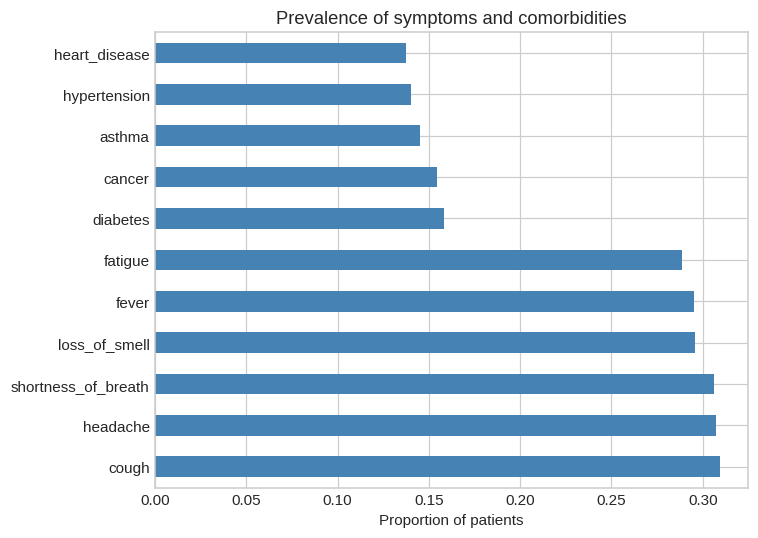

In [6]:
# ============================================================
# CELL 2e: How common is each symptom and condition?
# ============================================================
prevalence = df[SYMPTOMS + COMORBID].mean().sort_values(ascending=False)

print((prevalence * 100).round(1))

prevalence.plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.xlabel('Proportion of patients')
plt.title('Prevalence of symptoms and comorbidities')
plt.tight_layout()
plt.show()

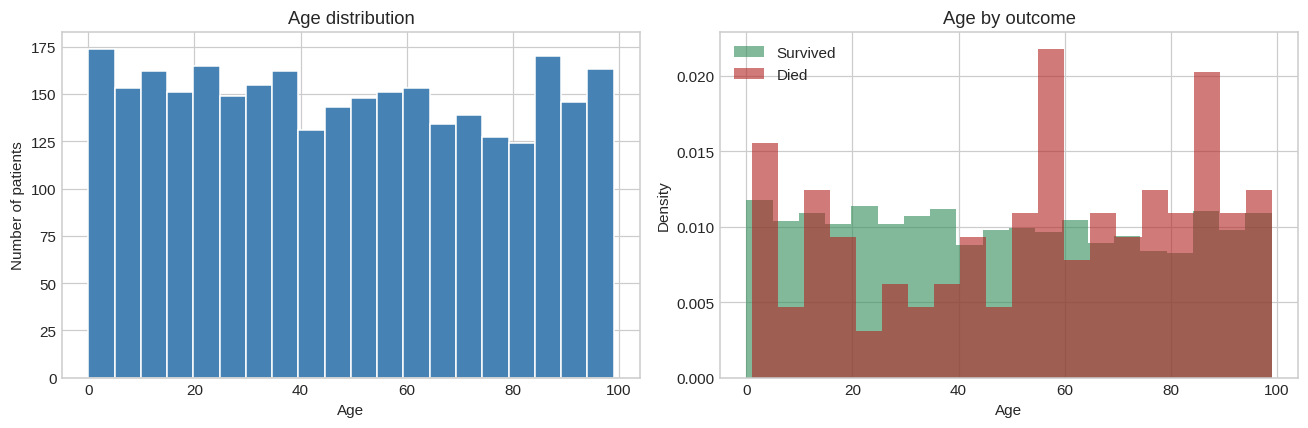

            count       mean        std
mortality                              
0          2869.0  48.231788  29.331563
1           131.0  54.755725  29.500219


In [7]:
# ============================================================
# CELL 3a: Age
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# overall age distribution
axes[0].hist(df['age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of patients')
axes[0].set_title('Age distribution')

# age distribution split by outcome
axes[1].hist(df[df.mortality == 0]['age'], bins=20, alpha=0.6,
             label='Survived', color='seagreen', density=True)
axes[1].hist(df[df.mortality == 1]['age'], bins=20, alpha=0.6,
             label='Died', color='firebrick', density=True)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].set_title('Age by outcome')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('mortality')['age'].describe()[['count', 'mean', 'std']])

             n  deaths      rate
age                             
[0, 18)    581      24  0.041308
[18, 35)   528      12  0.022727
[35, 50)   436      13  0.029817
[50, 65)   452      26  0.057522
[65, 80)   400      21  0.052500
[80, 100)  603      35  0.058043


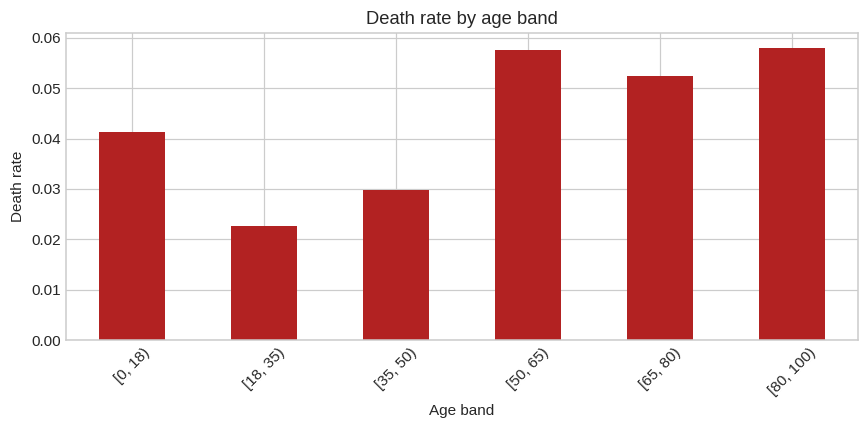

In [8]:
# ============================================================
# CELL 3b: Death rate across age bands
# ============================================================
bands = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 80, 100], right=False)
rates = df.groupby(bands, observed=True)[TARGET].agg(n='size', deaths='sum', rate='mean')

print(rates)

rates['rate'].plot(kind='bar', figsize=(8, 4), color='firebrick')
plt.ylabel('Death rate')
plt.xlabel('Age band')
plt.title('Death rate by age band')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

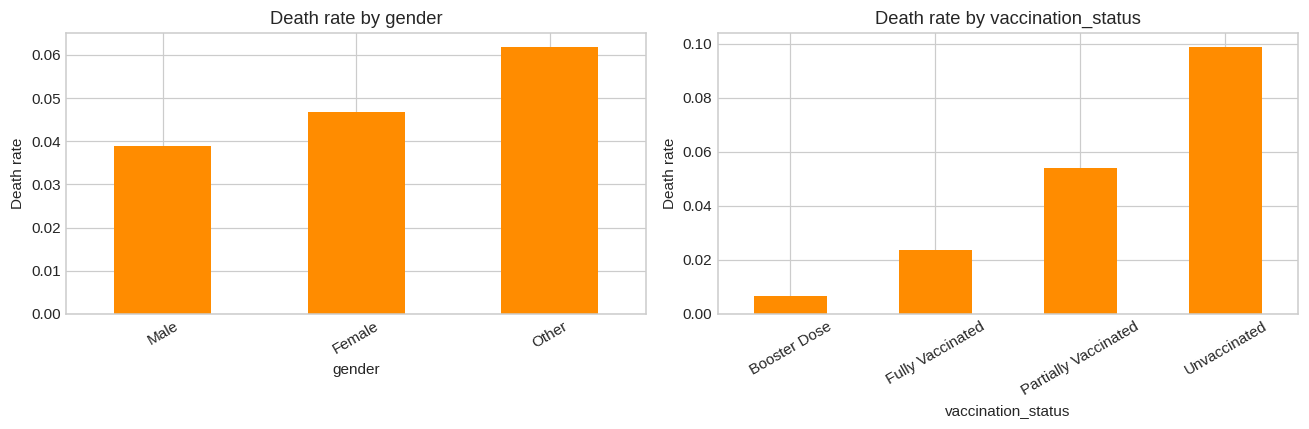


gender:
           n  deaths      rate
gender                        
Female  1451      68  0.046864
Male    1436      56  0.038997
Other    113       7  0.061947

vaccination_status:
                         n  deaths      rate
vaccination_status                          
Booster Dose           444       3  0.006757
Fully Vaccinated      1218      29  0.023810
Partially Vaccinated   742      40  0.053908
Unvaccinated           596      59  0.098993


In [9]:
# ============================================================
# CELL 3c: Death rate by categorical variables
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, CATEGORICAL):
    rate = df.groupby(col)[TARGET].mean().sort_values()
    rate.plot(kind='bar', ax=ax, color='darkorange')
    ax.set_ylabel('Death rate')
    ax.set_title(f'Death rate by {col}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

for col in CATEGORICAL:
    print(f'\n{col}:')
    print(df.groupby(col)[TARGET].agg(n='size', deaths='sum', rate='mean'))

            feature  rate_absent  rate_present  risk_ratio
      heart_disease        0.036         0.090       2.466
           headache        0.032         0.069       2.156
            fatigue        0.033         0.070       2.147
shortness_of_breath        0.033         0.069       2.098
              cough        0.033         0.067       2.006
              fever        0.035         0.065       1.896
             asthma        0.039         0.071       1.828
             cancer        0.039         0.067       1.694
      loss_of_smell        0.038         0.057       1.516
           diabetes        0.040         0.061       1.511
       hypertension        0.041         0.057       1.378


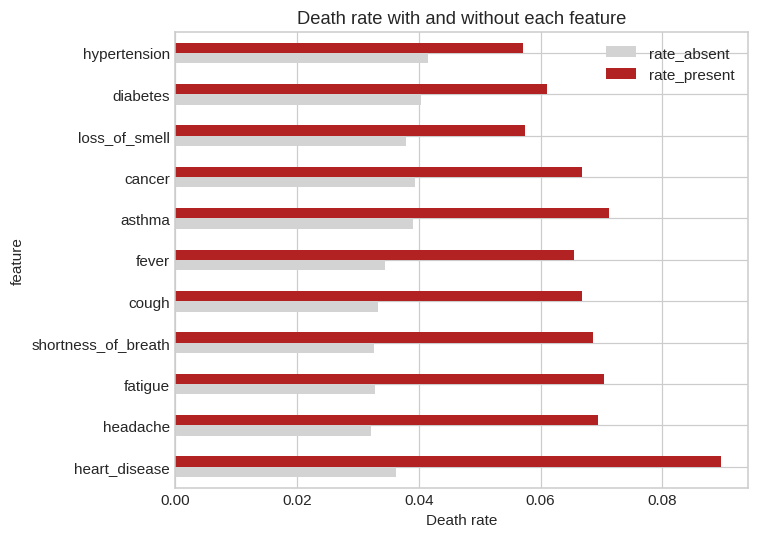

In [10]:
# ============================================================
# CELL 3d: Which symptoms and conditions raise the death rate?
# ============================================================
rows = []
for col in SYMPTOMS + COMORBID:
    absent  = df[df[col] == 0][TARGET].mean()
    present = df[df[col] == 1][TARGET].mean()
    rows.append({'feature': col,
                 'rate_absent': absent,
                 'rate_present': present,
                 'risk_ratio': present / absent})

comparison = pd.DataFrame(rows).sort_values('risk_ratio', ascending=False)
print(comparison.round(3).to_string(index=False))

comparison.set_index('feature')[['rate_absent', 'rate_present']].plot(
    kind='barh', figsize=(7, 5), color=['lightgrey', 'firebrick'])
plt.xlabel('Death rate')
plt.title('Death rate with and without each feature')
plt.tight_layout()
plt.show()

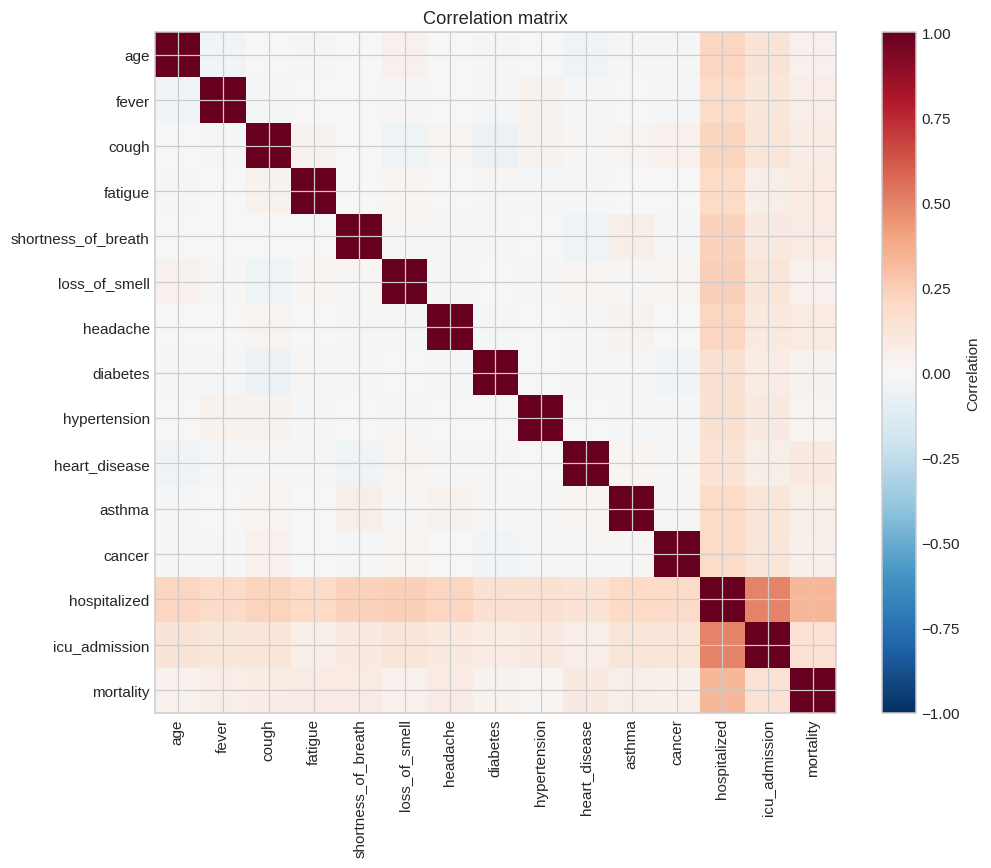

Correlation with mortality:
hospitalized           0.333
icu_admission          0.142
heart_disease          0.090
headache               0.084
fatigue                0.083
shortness_of_breath    0.081
cough                  0.076
fever                  0.069
asthma                 0.056
cancer                 0.048
age                    0.045
loss_of_smell          0.044
diabetes               0.037
hypertension           0.027
Name: mortality, dtype: float64


In [11]:
# ============================================================
# CELL 3e: Correlation between numeric features
# ============================================================
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.colorbar(im, label='Correlation')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

print('Correlation with mortality:')
print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

In [12]:
# ============================================================
# CELL 3f: Verify before cleaning
# ============================================================
# 1. Are the duplicates real repeated records, or chance collisions?
dupes = df[df.duplicated(keep=False)].sort_values(list(df.columns))
print(f'Rows involved in duplication: {len(dupes)}')
print('\nExample duplicated rows:')
print(dupes.head(6).to_string())

# Do the duplicates contain any deaths?
print(f'\nDeaths among duplicated rows: {dupes[TARGET].sum()}')

# 2. Is age = 0 real infants or a placeholder for missing?
print(f'\nPatients with age 0 : {(df.age == 0).sum()}')
print(f'Patients with age 1 : {(df.age == 1).sum()}')
print(f'Patients with age 2 : {(df.age == 2).sum()}')

Rows involved in duplication: 96

Example duplicated rows:
      age  gender    vaccination_status  fever  cough  fatigue  shortness_of_breath  loss_of_smell  headache  diabetes  hypertension  heart_disease  asthma  cancer  hospitalized  icu_admission  mortality
1718    2  Female  Partially Vaccinated      0      0        0                    1              1         0         0             0              0       0       0             0              0          0
2090    2  Female  Partially Vaccinated      0      0        0                    1              1         0         0             0              0       0       0             0              0          0
75      3  Female      Fully Vaccinated      0      0        0                    0              0         0         0             0              0       0       0             0              0          0
1134    3  Female      Fully Vaccinated      0      0        0                    0              0         0         0       

Observed duplicates       : 49
Simulated mean            : 23.3
Simulated 95% range       : 14 to 35


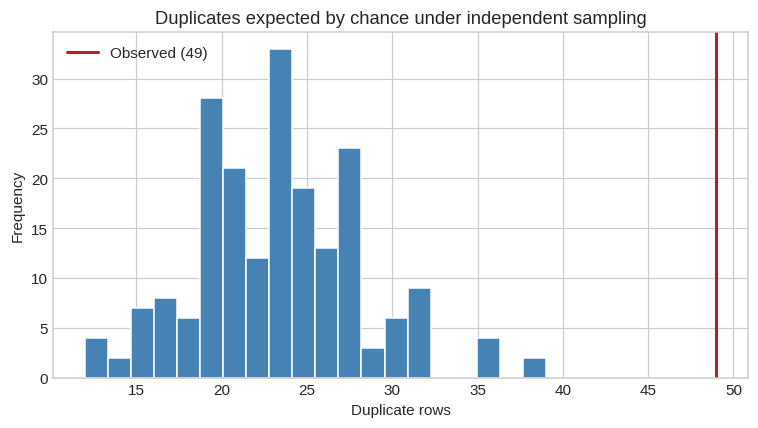

In [13]:
# ============================================================
# CELL 3g: Simulate duplicates under independent sampling
# ============================================================
# If each column was generated independently, we can rebuild fake
# datasets by shuffling each column separately. That destroys any
# row-level structure but keeps every column's distribution intact.
# If the shuffled data produces a similar number of duplicates,
# then our 49 are just chance collisions.

rng = np.random.default_rng(RANDOM_STATE)
simulated = []

for i in range(200):
    shuffled = df.apply(lambda col: rng.permutation(col.values))
    simulated.append(pd.DataFrame(shuffled).duplicated().sum())

simulated = np.array(simulated)

print(f'Observed duplicates       : {df.duplicated().sum()}')
print(f'Simulated mean            : {simulated.mean():.1f}')
print(f'Simulated 95% range       : {np.percentile(simulated, 2.5):.0f} '
      f'to {np.percentile(simulated, 97.5):.0f}')

plt.figure(figsize=(7, 4))
plt.hist(simulated, bins=20, color='steelblue', edgecolor='white')
plt.axvline(df.duplicated().sum(), color='firebrick', lw=2,
            label=f'Observed ({df.duplicated().sum()})')
plt.xlabel('Duplicate rows')
plt.ylabel('Frequency')
plt.title('Duplicates expected by chance under independent sampling')
plt.legend()
plt.tight_layout()
plt.show()

         all_patients  duplicated_rows
n_flags                               
0               0.061            0.375
1               0.179            0.354
2               0.269            0.167
3               0.254            0.083
4               0.156            0.021
5               0.059            0.000
6               0.018            0.000
7               0.005            0.000

Mean flags, all patients    : 2.54
Mean flags, duplicated rows : 1.02


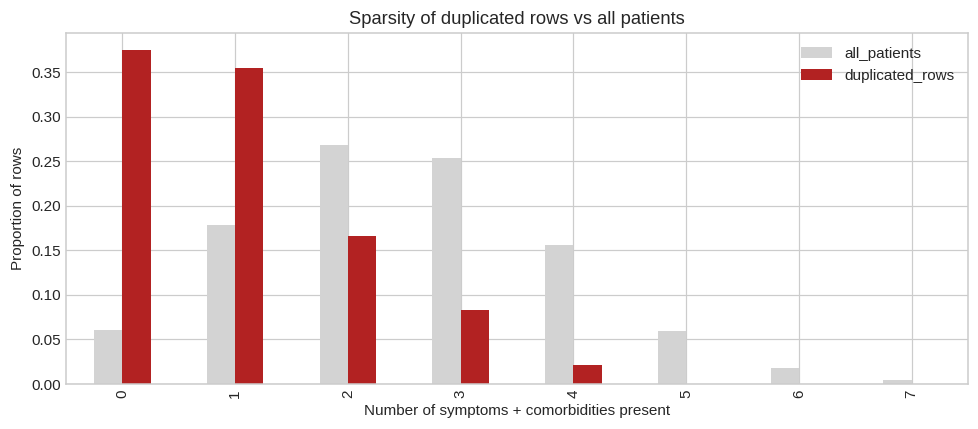

In [14]:
# ============================================================
# CELL 3h: Sparsity profile of duplicated rows
# ============================================================
# Chance collisions happen where probability mass piles up, which is
# among patients with few symptoms and few comorbidities.
# Genuinely repeated records would be copied at random, so their
# sparsity profile would look like the dataset as a whole.

flags = SYMPTOMS + COMORBID
df['n_flags'] = df[flags].sum(axis=1)

dup_mask = df.duplicated(keep=False)

compare = pd.DataFrame({
    'all_patients'   : df['n_flags'].value_counts(normalize=True).sort_index(),
    'duplicated_rows': df.loc[dup_mask, 'n_flags'].value_counts(normalize=True).sort_index()
}).fillna(0)

print(compare.round(3))
print(f"\nMean flags, all patients    : {df['n_flags'].mean():.2f}")
print(f"Mean flags, duplicated rows : {df.loc[dup_mask, 'n_flags'].mean():.2f}")

compare.plot(kind='bar', figsize=(9, 4), color=['lightgrey', 'firebrick'])
plt.xlabel('Number of symptoms + comorbidities present')
plt.ylabel('Proportion of rows')
plt.title('Sparsity of duplicated rows vs all patients')
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL 3i: Remove the helper column added in 3h
# ============================================================
df = df.drop(columns=['n_flags'])
print('Columns:', list(df.columns))
print('Shape:', df.shape)

Columns: ['age', 'gender', 'vaccination_status', 'fever', 'cough', 'fatigue', 'shortness_of_breath', 'loss_of_smell', 'headache', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'cancer', 'hospitalized', 'icu_admission', 'mortality']
Shape: (3000, 17)


In [16]:
# ============================================================
# CELL 4a: Chi-square tests for each feature against mortality
# ============================================================
from scipy.stats import chi2_contingency

results = []
for col in SYMPTOMS + COMORBID:
    table = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({'feature': col, 'chi2': round(chi2, 2),
                    'p_value': round(p, 4), 'significant': p < 0.05})

tests = pd.DataFrame(results).sort_values('p_value')
print(tests.to_string(index=False))

print(f"\nSignificant at p < 0.05: {tests.significant.sum()} of {len(tests)}")

for col in CATEGORICAL:
    chi2, p, dof, expected = chi2_contingency(pd.crosstab(df[col], df[TARGET]))
    print(f'{col:22s} chi2={chi2:7.2f}  p={p:.6f}')

            feature  chi2  p_value  significant
shortness_of_breath 18.80   0.0000         True
            fatigue 20.00   0.0000         True
           headache 20.34   0.0000         True
      heart_disease 22.93   0.0000         True
              cough 16.44   0.0001         True
              fever 13.57   0.0002         True
             asthma  8.52   0.0035         True
             cancer  6.40   0.0114         True
      loss_of_smell  5.27   0.0218         True
           diabetes  3.61   0.0576        False
       hypertension  1.77   0.1840        False

Significant at p < 0.05: 9 of 11
gender                 chi2=   2.01  p=0.366179
vaccination_status     chi2=  71.54  p=0.000000


In [17]:
# ============================================================
# CELL 4b: Cleaning and feature engineering
# ============================================================
data = df.copy()

# Duplicates KEPT. Cell 3h showed duplicated rows average 1.02
# symptom/comorbidity flags versus 2.54 across all patients, and the
# all-zero profile is 37.5% of duplicates but only 6.1% of patients.
# That concentration in sparse profiles is the signature of chance
# collision, not repeated patient records.

# Drop the leaky outcome columns.
# hospitalized : 0.0% death rate among non-hospitalised patients, so it
#                perfectly separates the target.
# icu_admission: ICU patients die at 13.6% vs 15.6% for hospitalised
#                non-ICU patients, which is clinically impossible.
data = data.drop(columns=['hospitalized', 'icu_admission'])
print('Shape after dropping leaky columns:', data.shape)

# Count features: total symptom and comorbidity burden.
data['symptom_count']     = data[SYMPTOMS].sum(axis=1)
data['comorbidity_count'] = data[COMORBID].sum(axis=1)

print('\nDeath rate by number of symptoms:')
print(data.groupby('symptom_count')[TARGET].agg(n='size', deaths='sum', rate='mean'))

print('\nDeath rate by number of comorbidities:')
print(data.groupby('comorbidity_count')[TARGET].agg(n='size', deaths='sum', rate='mean'))

Shape after dropping leaky columns: (3000, 15)

Death rate by number of symptoms:
                 n  deaths      rate
symptom_count                       
0              364       0  0.000000
1              885      10  0.011299
2              985      46  0.046701
3              549      45  0.081967
4              182      28  0.153846
5               32       2  0.062500
6                3       0  0.000000

Death rate by number of comorbidities:
                      n  deaths      rate
comorbidity_count                        
0                  1351      30  0.022206
1                  1187      60  0.050548
2                   371      31  0.083558
3                    86      10  0.116279
4                     5       0  0.000000


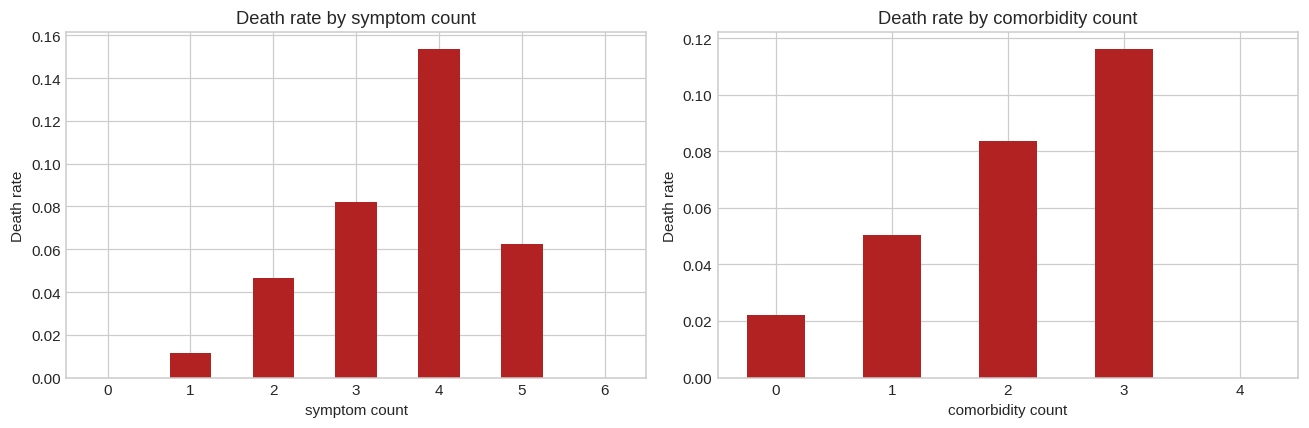

In [18]:
# ============================================================
# CELL 4c: Visual check on the engineered features
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['symptom_count', 'comorbidity_count']):
    rate = data.groupby(col)[TARGET].mean()
    rate.plot(kind='bar', ax=ax, color='firebrick')
    ax.set_ylabel('Death rate')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_title(f'Death rate by {col.replace("_", " ")}')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 4d: Encoding and train/test split
# ============================================================
from sklearn.model_selection import train_test_split

# One-hot encode the two text columns.
# drop_first=True avoids the dummy variable trap in logistic regression.
X = pd.get_dummies(data.drop(columns=[TARGET]),
                   columns=CATEGORICAL, drop_first=True).astype(float)
y = data[TARGET]

print('Feature matrix:', X.shape)
print('\nFeatures:')
for c in X.columns:
    print(' -', c)

# Stratify so the 131 deaths split proportionally between train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f'\nTrain: {len(X_train)} patients, {y_train.sum()} deaths ({y_train.mean():.2%})')
print(f'Test : {len(X_test)} patients, {y_test.sum()} deaths ({y_test.mean():.2%})')

Feature matrix: (3000, 19)

Features:
 - age
 - fever
 - cough
 - fatigue
 - shortness_of_breath
 - loss_of_smell
 - headache
 - diabetes
 - hypertension
 - heart_disease
 - asthma
 - cancer
 - symptom_count
 - comorbidity_count
 - gender_Male
 - gender_Other
 - vaccination_status_Fully Vaccinated
 - vaccination_status_Partially Vaccinated
 - vaccination_status_Unvaccinated

Train: 2250 patients, 98 deaths (4.36%)
Test : 750 patients, 33 deaths (4.40%)


In [20]:
# ============================================================
# CELL 4e: Two feature sets, avoiding collinearity
# ============================================================
# symptom_count is the exact sum of the 6 symptom columns, and
# comorbidity_count the exact sum of the 5 comorbidity columns.
# Keeping both the counts and their components creates perfect
# multicollinearity, which makes logistic regression coefficients
# unstable and uninterpretable. So we build two separate sets.

base = data.drop(columns=[TARGET])

# SET A: individual indicators, no counts.
# Lets us read an odds ratio per symptom and per condition.
set_a = base.drop(columns=['symptom_count', 'comorbidity_count'])

# SET B: counts only, no individual indicators.
# Simpler, fewer parameters, better suited to 98 training deaths.
set_b = base.drop(columns=SYMPTOMS + COMORBID)

X_a = pd.get_dummies(set_a, columns=CATEGORICAL, drop_first=True).astype(float)
X_b = pd.get_dummies(set_b, columns=CATEGORICAL, drop_first=True).astype(float)
y   = data[TARGET]

print('Set A (indicators):', X_a.shape[1], 'features ->', list(X_a.columns))
print('\nSet B (counts)    :', X_b.shape[1], 'features ->', list(X_b.columns))

print(f'\nEvents per variable, Set A: {y.sum() * 0.75 / X_a.shape[1]:.1f}')
print(f'Events per variable, Set B: {y.sum() * 0.75 / X_b.shape[1]:.1f}')

Set A (indicators): 17 features -> ['age', 'fever', 'cough', 'fatigue', 'shortness_of_breath', 'loss_of_smell', 'headache', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'cancer', 'gender_Male', 'gender_Other', 'vaccination_status_Fully Vaccinated', 'vaccination_status_Partially Vaccinated', 'vaccination_status_Unvaccinated']

Set B (counts)    : 8 features -> ['age', 'symptom_count', 'comorbidity_count', 'gender_Male', 'gender_Other', 'vaccination_status_Fully Vaccinated', 'vaccination_status_Partially Vaccinated', 'vaccination_status_Unvaccinated']

Events per variable, Set A: 5.8
Events per variable, Set B: 12.3


In [21]:
# ============================================================
# CELL 4f: Verify collinearity is gone, then split
# ============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

def vif_table(X):
    return pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)

print('Set A, highest VIFs:')
print(vif_table(X_a).head(5).round(2).to_string(index=False))

print('\nSet B, highest VIFs:')
print(vif_table(X_b).head(5).round(2).to_string(index=False))

# Same seed for both so the two sets share identical train/test patients.
Xa_train, Xa_test, y_train, y_test = train_test_split(
    X_a, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
Xb_train, Xb_test, _, _ = train_test_split(
    X_b, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f'\nTrain: {len(Xa_train)} patients, {y_train.sum()} deaths')
print(f'Test : {len(Xa_test)} patients, {y_test.sum()} deaths')

Set A, highest VIFs:
                                feature  VIF
    vaccination_status_Fully Vaccinated 2.24
vaccination_status_Partially Vaccinated 2.02
        vaccination_status_Unvaccinated 1.89
                            gender_Male 1.05
                           gender_Other 1.04

Set B, highest VIFs:
                                feature  VIF
    vaccination_status_Fully Vaccinated 2.23
vaccination_status_Partially Vaccinated 2.01
        vaccination_status_Unvaccinated 1.88
                           gender_Other 1.04
                            gender_Male 1.04

Train: 2250 patients, 98 deaths
Test : 750 patients, 33 deaths


In [22]:
# ============================================================
# CELL 5a: Logistic regression on Set A and Set B
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

# Scaling goes inside a Pipeline so it is fitted on the training folds
# only. Fitting a scaler on all the data first would leak test-set
# means and standard deviations into training.
# class_weight='balanced' handles the 21.9:1 imbalance by penalising
# errors on the minority class more heavily, rather than deleting or
# duplicating rows.
def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000,
                                   class_weight='balanced',
                                   random_state=RANDOM_STATE))
    ])

sets = {
    'Set A (indicators)': (Xa_train, Xa_test),
    'Set B (counts)'    : (Xb_train, Xb_test),
}

models = {}
for name, (Xtr, Xte) in sets.items():
    model = make_logreg()
    model.fit(Xtr, y_train)
    models[name] = model

    prob = model.predict_proba(Xte)[:, 1]
    print(f'{name}')
    print(f'   ROC-AUC : {roc_auc_score(y_test, prob):.3f}')
    print(f'   PR-AUC  : {average_precision_score(y_test, prob):.3f}'
          f'   (no-skill baseline = {y_test.mean():.3f})')

Set A (indicators)
   ROC-AUC : 0.842
   PR-AUC  : 0.155   (no-skill baseline = 0.044)
Set B (counts)
   ROC-AUC : 0.866
   PR-AUC  : 0.162   (no-skill baseline = 0.044)


In [23]:
# ============================================================
# CELL 5b: 5-fold cross-validation on the training set
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# 33 deaths in the test set means a handful of patients can swing the
# metrics. Cross-validation on the training data gives a more stable
# estimate before we commit to a final model.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, (Xtr, Xte) in sets.items():
    prob = cross_val_predict(make_logreg(), Xtr, y_train,
                             cv=cv, method='predict_proba')[:, 1]
    print(f'{name}')
    print(f'   CV ROC-AUC : {roc_auc_score(y_train, prob):.3f}')
    print(f'   CV PR-AUC  : {average_precision_score(y_train, prob):.3f}')

Set A (indicators)
   CV ROC-AUC : 0.862
   CV PR-AUC  : 0.159
Set B (counts)
   CV ROC-AUC : 0.868
   CV PR-AUC  : 0.154


                                feature  coefficient  odds_ratio
        vaccination_status_Unvaccinated        1.519       4.567
vaccination_status_Partially Vaccinated        1.069       2.912
                    shortness_of_breath        0.926       2.525
                               headache        0.720       2.055
                                fatigue        0.710       2.033
                          heart_disease        0.690       1.994
    vaccination_status_Fully Vaccinated        0.643       1.902
                          loss_of_smell        0.529       1.697
                                  cough        0.522       1.685
                                  fever        0.490       1.633
                                 cancer        0.461       1.585
                                 asthma        0.450       1.569
                               diabetes        0.421       1.523
                                    age        0.417       1.518
                         

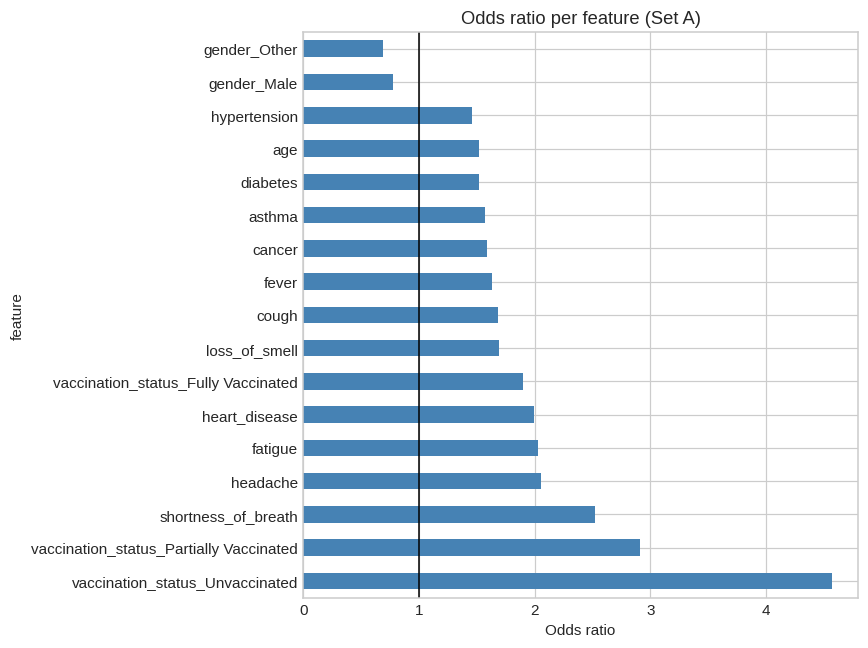

In [24]:
# ============================================================
# CELL 5c: Odds ratios from Set A
# ============================================================
model = models['Set A (indicators)']
coefs = model.named_steps['clf'].coef_[0]

odds = pd.DataFrame({
    'feature': Xa_train.columns,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs)
}).sort_values('odds_ratio', ascending=False)

print(odds.round(3).to_string(index=False))

odds.set_index('feature')['odds_ratio'].plot(
    kind='barh', figsize=(8, 6), color='steelblue')
plt.axvline(1, color='black', lw=1)
plt.xlabel('Odds ratio')
plt.title('Odds ratio per feature (Set A)')
plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL 5d: Interpretable odds ratios with confidence intervals
# ============================================================
import statsmodels.api as sm

# Scaling made the binary coefficients "per standard deviation", which
# is not interpretable for a 0/1 column. Here we fit unscaled, so each
# odds ratio reads as "odds multiplier when the feature is present",
# except age which is per year. statsmodels also gives us the
# confidence intervals and p-values that sklearn does not.

X_sm = sm.add_constant(Xa_train)
logit = sm.Logit(y_train, X_sm).fit(disp=False)

summary = pd.DataFrame({
    'odds_ratio': np.exp(logit.params),
    'ci_lower'  : np.exp(logit.conf_int()[0]),
    'ci_upper'  : np.exp(logit.conf_int()[1]),
    'p_value'   : logit.pvalues
}).drop('const').sort_values('odds_ratio', ascending=False)

print(summary.round(3).to_string())
print('\nFeatures whose CI excludes 1 (a real effect):')
print(summary[(summary.ci_lower > 1) | (summary.ci_upper < 1)].index.tolist())

                                         odds_ratio  ci_lower  ci_upper  p_value
vaccination_status_Unvaccinated              13.554     4.061    45.237    0.000
vaccination_status_Partially Vaccinated       5.120     1.511    17.345    0.009
heart_disease                                 3.855     2.298     6.467    0.000
shortness_of_breath                           3.544     2.261     5.553    0.000
fatigue                                       2.770     1.781     4.308    0.000
headache                                      2.427     1.565     3.763    0.000
vaccination_status_Fully Vaccinated           2.420     0.709     8.265    0.158
diabetes                                      2.364     1.398     3.999    0.001
asthma                                        2.083     1.245     3.485    0.005
cough                                         1.977     1.261     3.100    0.003
fever                                         1.874     1.190     2.951    0.007
cancer                      

In [26]:
# ============================================================
# CELL 5e: Random Forest and Gradient Boosting on Set B
# ============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Set B won, so we compare algorithms on Set B only.
# Trees are deliberately shallow: with 98 training deaths, deep trees
# memorise rather than generalise.
candidates = {
    'Logistic Regression': make_logreg(),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=20,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=RANDOM_STATE),
}

print(f"{'Model':<22}{'CV ROC-AUC':>12}{'CV PR-AUC':>12}"
      f"{'Test ROC-AUC':>14}{'Test PR-AUC':>13}")

fitted = {}
for name, clf in candidates.items():
    cv_prob = cross_val_predict(clf, Xb_train, y_train,
                                cv=cv, method='predict_proba')[:, 1]
    clf.fit(Xb_train, y_train)
    fitted[name] = clf
    te_prob = clf.predict_proba(Xb_test)[:, 1]

    print(f'{name:<22}{roc_auc_score(y_train, cv_prob):>12.3f}'
          f'{average_precision_score(y_train, cv_prob):>12.3f}'
          f'{roc_auc_score(y_test, te_prob):>14.3f}'
          f'{average_precision_score(y_test, te_prob):>13.3f}')

print(f"\nNo-skill PR-AUC baseline: {y_test.mean():.3f}")

Model                   CV ROC-AUC   CV PR-AUC  Test ROC-AUC  Test PR-AUC
Logistic Regression          0.868       0.154         0.866        0.162
Random Forest                0.848       0.138         0.828        0.160
Gradient Boosting            0.834       0.129         0.801        0.137

No-skill PR-AUC baseline: 0.044


In [27]:
# ============================================================
# CELL 6a: Performance across decision thresholds
# ============================================================
from sklearn.metrics import confusion_matrix

best_model = fitted['Logistic Regression']
prob = best_model.predict_proba(Xb_test)[:, 1]

rows = []
for t in np.arange(0.05, 1.0, 0.05):
    pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append({
        'threshold'  : round(t, 2),
        'flagged'    : pred.sum(),
        'caught'     : tp,
        'missed'     : fn,
        'sensitivity': tp / (tp + fn) if (tp + fn) else 0,
        'specificity': tn / (tn + fp) if (tn + fp) else 0,
        'precision'  : tp / (tp + fp) if (tp + fp) else 0,
    })

sweep = pd.DataFrame(rows)
print(sweep.round(3).to_string(index=False))

 threshold  flagged  caught  missed  sensitivity  specificity  precision
      0.05      539      33       0        1.000        0.294      0.061
      0.10      456      33       0        1.000        0.410      0.072
      0.15      390      33       0        1.000        0.502      0.085
      0.20      351      33       0        1.000        0.556      0.094
      0.25      315      33       0        1.000        0.607      0.105
      0.30      281      31       2        0.939        0.651      0.110
      0.35      256      31       2        0.939        0.686      0.121
      0.40      238      31       2        0.939        0.711      0.130
      0.45      221      31       2        0.939        0.735      0.140
      0.50      208      30       3        0.909        0.752      0.144
      0.55      198      30       3        0.909        0.766      0.152
      0.60      167      28       5        0.848        0.806      0.168
      0.65      150      22      11        0.667   

In [28]:
# ============================================================
# CELL 6b: Choose a threshold and evaluate there
# ============================================================
from sklearn.metrics import classification_report

# In triage, missing a death is far worse than a false alarm.
# So we fix sensitivity at 80% or better and take the threshold
# that gives the best specificity under that constraint, rather
# than defaulting to 0.5 which optimises for the majority class.
eligible = sweep[sweep.sensitivity >= 0.80]
T = eligible.loc[eligible.specificity.idxmax(), 'threshold']
print(f'Chosen threshold: {T}\n')

pred = (prob >= T).astype(int)
print(classification_report(y_test, pred,
                            target_names=['Survived', 'Died'], digits=3))

cm = confusion_matrix(y_test, pred)
print('                pred survive   pred die')
print(f'true survive  {cm[0,0]:>12}  {cm[0,1]:>9}')
print(f'true die      {cm[1,0]:>12}  {cm[1,1]:>9}')

print(f'\nOf {pred.sum()} patients flagged, {cm[1,1]} actually died.')
print(f'{cm[1,0]} deaths were missed entirely.')

Chosen threshold: 0.6

              precision    recall  f1-score   support

    Survived      0.991     0.806     0.889       717
        Died      0.168     0.848     0.280        33

    accuracy                          0.808       750
   macro avg      0.580     0.827     0.585       750
weighted avg      0.955     0.808     0.862       750

                pred survive   pred die
true survive           578        139
true die                 5         28

Of 167 patients flagged, 28 actually died.
5 deaths were missed entirely.


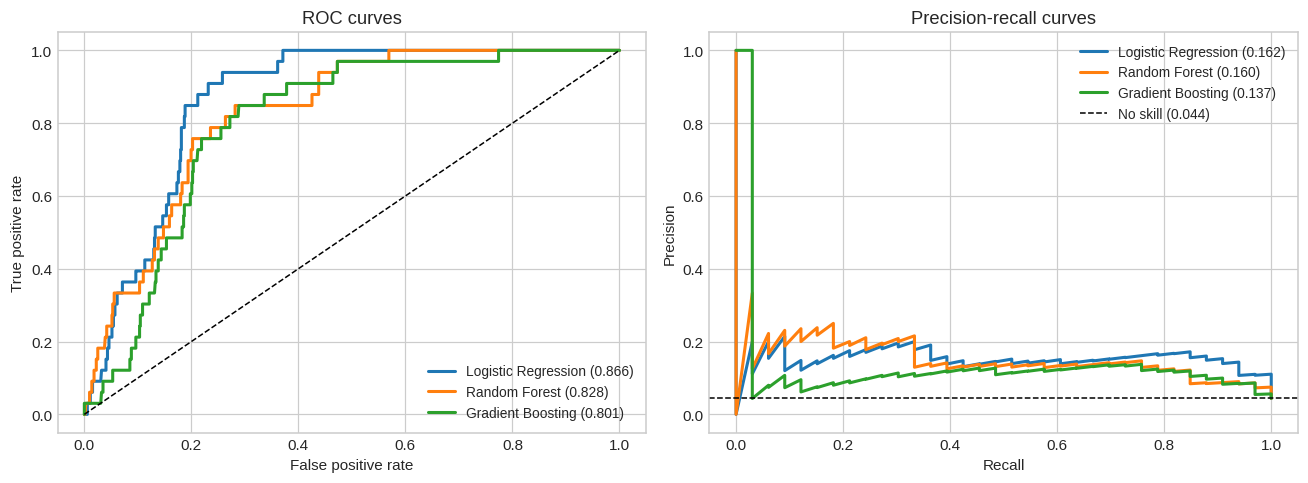

In [29]:
# ============================================================
# CELL 6c: ROC and precision-recall curves
# ============================================================
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for name, clf in fitted.items():
    p = clf.predict_proba(Xb_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} ({roc_auc_score(y_test, p):.3f})')

    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, lw=2,
                 label=f'{name} ({average_precision_score(y_test, p):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title='ROC curves')
axes[0].legend(loc='lower right', fontsize=9)

axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1,
                label=f'No skill ({y_test.mean():.3f})')
axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision-recall curves')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

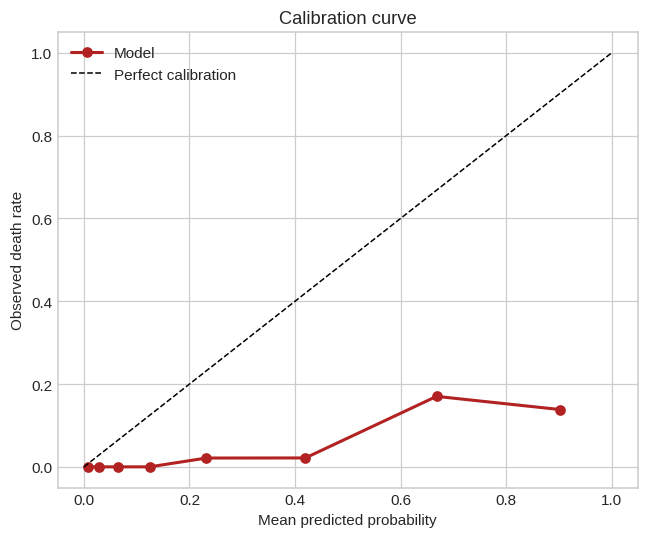

Brier score: 0.1703
Mean predicted risk : 0.306
Actual death rate   : 0.044


In [30]:
# ============================================================
# CELL 7a: Calibration check
# ============================================================
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# AUC only cares about ranking. Calibration asks a different question:
# when the model says 30%, do 30% of those patients actually die?
# This matters because class_weight='balanced' deliberately distorts
# the predicted probabilities upward.
frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=8, strategy='quantile')

plt.figure(figsize=(6, 5))
plt.plot(mean_pred, frac_pos, 'o-', lw=2, color='firebrick', label='Model')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed death rate')
plt.title('Calibration curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Brier score: {brier_score_loss(y_test, prob):.4f}')
print(f'Mean predicted risk : {prob.mean():.3f}')
print(f'Actual death rate   : {y_test.mean():.3f}')

ROC-AUC over 30 splits: 0.871 (sd 0.013, range 0.843 to 0.893)
PR-AUC  over 30 splits: 0.172 (sd 0.022, range 0.127 to 0.216)


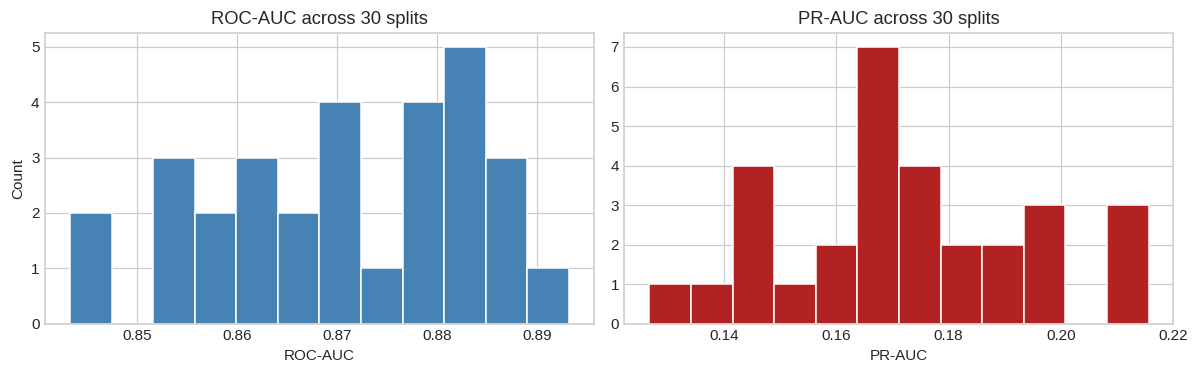

In [31]:
# ============================================================
# CELL 7b: Repeated splits to check stability
# ============================================================
# 33 deaths in one test set is thin. Repeating the split with
# different seeds shows how much the headline numbers move by luck.
roc_scores, pr_scores = [], []

for seed in range(30):
    Xtr, Xte, ytr, yte = train_test_split(
        X_b, y, test_size=0.25, stratify=y, random_state=seed)
    m = make_logreg().fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    roc_scores.append(roc_auc_score(yte, p))
    pr_scores.append(average_precision_score(yte, p))

roc_scores, pr_scores = np.array(roc_scores), np.array(pr_scores)

print(f'ROC-AUC over 30 splits: {roc_scores.mean():.3f} '
      f'(sd {roc_scores.std():.3f}, range {roc_scores.min():.3f} to {roc_scores.max():.3f})')
print(f'PR-AUC  over 30 splits: {pr_scores.mean():.3f} '
      f'(sd {pr_scores.std():.3f}, range {pr_scores.min():.3f} to {pr_scores.max():.3f})')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(roc_scores, bins=12, color='steelblue', edgecolor='white')
axes[0].set(xlabel='ROC-AUC', ylabel='Count', title='ROC-AUC across 30 splits')
axes[1].hist(pr_scores, bins=12, color='firebrick', edgecolor='white')
axes[1].set(xlabel='PR-AUC', title='PR-AUC across 30 splits')
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CELL 7c: Save per-patient risk scores
# ============================================================
results = Xb_test.copy()
results['actual_died']    = y_test.values
results['predicted_risk'] = prob
results['flagged']        = (prob >= T).astype(int)
results = results.sort_values('predicted_risk', ascending=False)

results.to_csv('/content/drive/MyDrive/covid_risk_scores.csv', index=False)
print('Saved to Drive.')

print('\nHighest-risk patients:')
print(results.head(10).to_string())

print('\nThe 5 deaths the model missed:')
print(results[(results.actual_died == 1) & (results.flagged == 0)].to_string())

Saved to Drive.

Highest-risk patients:
       age  symptom_count  comorbidity_count  gender_Male  gender_Other  vaccination_status_Fully Vaccinated  vaccination_status_Partially Vaccinated  vaccination_status_Unvaccinated  actual_died  predicted_risk  flagged
4     60.0            4.0                3.0          1.0           0.0                                  0.0                                      0.0                              1.0            0        0.998460        1
714   37.0            6.0                0.0          1.0           0.0                                  0.0                                      0.0                              1.0            0        0.993438        1
492   15.0            5.0                2.0          0.0           1.0                                  0.0                                      0.0                              1.0            0        0.990359        1
902   79.0            3.0                2.0          0.0           0.0     

In [33]:
# ============================================================
# CELL 7d: Does removing class weighting fix calibration?
# ============================================================
from sklearn.calibration import CalibratedClassifierCV

variants = {
    'Balanced (current)': make_logreg(),
    'Unweighted': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Balanced + isotonic recalibration': CalibratedClassifierCV(
        make_logreg(), method='isotonic', cv=5),
}

print(f"{'Model':<36}{'ROC-AUC':>10}{'PR-AUC':>10}{'Brier':>10}{'Mean pred':>12}")
for name, m in variants.items():
    m.fit(Xb_train, y_train)
    p = m.predict_proba(Xb_test)[:, 1]
    print(f'{name:<36}{roc_auc_score(y_test, p):>10.3f}'
          f'{average_precision_score(y_test, p):>10.3f}'
          f'{brier_score_loss(y_test, p):>10.4f}{p.mean():>12.3f}')

print(f"\nActual death rate: {y_test.mean():.3f}")
print(f"Always-predict-base-rate Brier: "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_test.mean())):.4f}")

Model                                  ROC-AUC    PR-AUC     Brier   Mean pred
Balanced (current)                       0.866     0.162    0.1703       0.306
Unweighted                               0.864     0.164    0.0403       0.047
Balanced + isotonic recalibration        0.867     0.161    0.0387       0.049

Actual death rate: 0.044
Always-predict-base-rate Brier: 0.0421


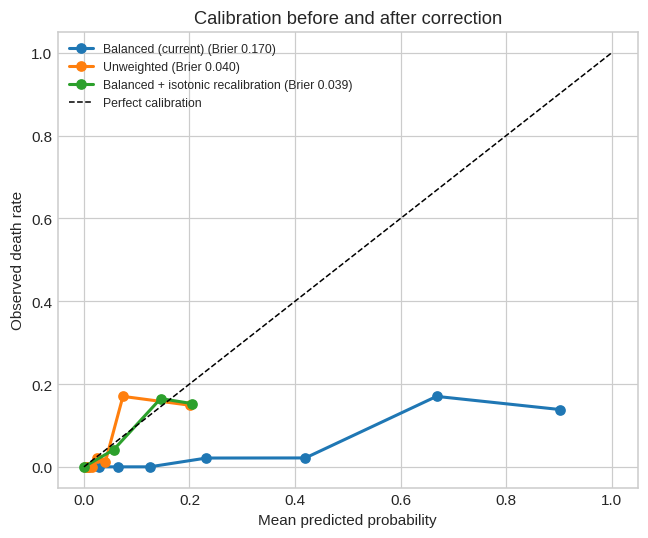

In [34]:
# ============================================================
# CELL 7e: Compare calibration across the three variants
# ============================================================
plt.figure(figsize=(6, 5))

for name, m in variants.items():
    p = m.predict_proba(Xb_test)[:, 1]
    frac, mean_p = calibration_curve(y_test, p, n_bins=8, strategy='quantile')
    plt.plot(mean_p, frac, 'o-', lw=2, label=f'{name} (Brier {brier_score_loss(y_test, p):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed death rate')
plt.title('Calibration before and after correction')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# CELL 7f: Final model, unweighted, with a fresh threshold sweep
# ============================================================
# Cell 7d showed class weighting left discrimination unchanged
# (ROC-AUC 0.866 vs 0.864) while inflating predicted risk sevenfold
# (Brier 0.1703 vs 0.0403). We drop it and control recall through
# the threshold instead.
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
]).fit(Xb_train, y_train)

prob_final = final_model.predict_proba(Xb_test)[:, 1]
print(f'Predicted risk ranges {prob_final.min():.3f} to {prob_final.max():.3f}\n')

# The scale has changed, so the old threshold of 0.60 no longer applies.
rows = []
for t in np.arange(0.01, 0.31, 0.01):
    pred = (prob_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append({'threshold': round(t, 2), 'flagged': pred.sum(),
                 'caught': tp, 'missed': fn,
                 'sensitivity': tp/(tp+fn) if (tp+fn) else 0,
                 'specificity': tn/(tn+fp) if (tn+fp) else 0,
                 'precision': tp/(tp+fp) if (tp+fp) else 0})

sweep_final = pd.DataFrame(rows)
print(sweep_final.round(3).to_string(index=False))

eligible = sweep_final[sweep_final.sensitivity >= 0.80]
T_final = eligible.loc[eligible.specificity.idxmax(), 'threshold']
print(f'\nChosen threshold: {T_final}')
print(sweep_final[sweep_final.threshold == T_final].round(3).to_string(index=False))

Predicted risk ranges 0.000 to 0.688

 threshold  flagged  caught  missed  sensitivity  specificity  precision
      0.01      517      33       0        1.000        0.325      0.064
      0.02      370      33       0        1.000        0.530      0.089
      0.03      283      31       2        0.939        0.649      0.110
      0.04      231      31       2        0.939        0.721      0.134
      0.05      196      31       2        0.939        0.770      0.158
      0.06      171      28       5        0.848        0.801      0.164
      0.07      145      22      11        0.667        0.828      0.152
      0.08      126      16      17        0.485        0.847      0.127
      0.09      109      15      18        0.455        0.869      0.138
      0.10       95      14      19        0.424        0.887      0.147
      0.11       82      13      20        0.394        0.904      0.159
      0.12       75      12      21        0.364        0.912      0.160
      0.13   

In [36]:
# ============================================================
# CELL 8a: Sensitivity check on the duplicate decision
# ============================================================
def make_final():
    return Pipeline([('scaler', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=2000,
                                                random_state=RANDOM_STATE))])

data_nodup = data.drop_duplicates().reset_index(drop=True)
X_nd = pd.get_dummies(data_nodup.drop(columns=[TARGET] + SYMPTOMS + COMORBID),
                      columns=CATEGORICAL, drop_first=True).astype(float)
y_nd = data_nodup[TARGET]

print(f'With duplicates   : {len(X_b)} rows, {y.sum()} deaths')
print(f'Without duplicates: {len(X_nd)} rows, {y_nd.sum()} deaths\n')

for label, Xd, yd in [('Kept', X_b, y), ('Removed', X_nd, y_nd)]:
    roc, pr = [], []
    for seed in range(30):
        Xtr, Xte, ytr, yte = train_test_split(
            Xd, yd, test_size=0.25, stratify=yd, random_state=seed)
        m = make_final().fit(Xtr, ytr)
        p = m.predict_proba(Xte)[:, 1]
        roc.append(roc_auc_score(yte, p))
        pr.append(average_precision_score(yte, p))
    print(f'Duplicates {label:<8} ROC-AUC {np.mean(roc):.3f} (sd {np.std(roc):.3f})  '
          f'PR-AUC {np.mean(pr):.3f} (sd {np.std(pr):.3f})')

With duplicates   : 3000 rows, 131 deaths
Without duplicates: 2949 rows, 129 deaths

Duplicates Kept     ROC-AUC 0.866 (sd 0.015)  PR-AUC 0.167 (sd 0.021)
Duplicates Removed  ROC-AUC 0.863 (sd 0.023)  PR-AUC 0.165 (sd 0.033)


In [37]:
# ============================================================
# CELL 8b: Final numbers for the report
# ============================================================
# Stability of the final unweighted model across 30 splits
roc_f, pr_f = [], []
for seed in range(30):
    Xtr, Xte, ytr, yte = train_test_split(
        X_b, y, test_size=0.25, stratify=y, random_state=seed)
    m = make_final().fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    roc_f.append(roc_auc_score(yte, p))
    pr_f.append(average_precision_score(yte, p))

summary_rows = {
    'Patients'                 : len(X_b),
    'Deaths'                   : int(y.sum()),
    'Death rate'               : f'{y.mean():.2%}',
    'Imbalance ratio'          : f'{(y==0).sum()/(y==1).sum():.1f}:1',
    'Features (Set B)'         : X_b.shape[1],
    'Events per variable'      : f'{y.sum()*0.75/X_b.shape[1]:.1f}',
    'Final model'              : 'Logistic regression, unweighted',
    'ROC-AUC (30 splits)'      : f'{np.mean(roc_f):.3f} (SD {np.std(roc_f):.3f})',
    'PR-AUC (30 splits)'       : f'{np.mean(pr_f):.3f} (SD {np.std(pr_f):.3f})',
    'PR-AUC no-skill baseline' : f'{y.mean():.3f}',
    'Brier score'              : '0.0403 (base-rate benchmark 0.0421)',
    'Operating threshold'      : T_final,
    'Sensitivity'              : '0.848',
    'Specificity'              : '0.801',
    'Precision'                : '0.164',
    'Deaths caught / missed'   : '28 / 5',
    'Patients flagged'         : '171 of 750 (22.8%)',
}
print(pd.Series(summary_rows).to_string())

Patients                                                   3000
Deaths                                                      131
Death rate                                                4.37%
Imbalance ratio                                          21.9:1
Features (Set B)                                              8
Events per variable                                        12.3
Final model                     Logistic regression, unweighted
ROC-AUC (30 splits)                            0.866 (SD 0.015)
PR-AUC (30 splits)                             0.167 (SD 0.021)
PR-AUC no-skill baseline                                  0.044
Brier score                 0.0403 (base-rate benchmark 0.0421)
Operating threshold                                        0.06
Sensitivity                                               0.848
Specificity                                               0.801
Precision                                                 0.164
Deaths caught / missed                  

In [38]:
# ============================================================
# CELL 9a: Fit the final model on all data and save it
# ============================================================
import joblib

# The train/test split existed to get an honest performance estimate.
# Now that we have it, refit on all 3000 patients so the deployed
# model uses every available row.
deploy_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
]).fit(X_b, y)

# Save the whole Pipeline, not just the classifier. The scaler's
# means and standard deviations are part of the model, and a
# classifier without them produces nonsense on raw inputs.
bundle = {
    'model': deploy_model,
    'feature_order': list(X_b.columns),
    'threshold': 0.06,
    'metrics': {'roc_auc': 0.866, 'pr_auc': 0.167,
                'sensitivity': 0.848, 'specificity': 0.801,
                'precision': 0.164},
}

joblib.dump(bundle, '/content/drive/MyDrive/covid_model.joblib')
print('Saved.')
print('Feature order:', bundle['feature_order'])

# Sanity check: reload and confirm it gives the same answer
reloaded = joblib.load('/content/drive/MyDrive/covid_model.joblib')
test_row = X_b.iloc[[0]]
print('\nOriginal :', deploy_model.predict_proba(test_row)[0, 1].round(6))
print('Reloaded :', reloaded['model'].predict_proba(test_row)[0, 1].round(6))

Saved.
Feature order: ['age', 'symptom_count', 'comorbidity_count', 'gender_Male', 'gender_Other', 'vaccination_status_Fully Vaccinated', 'vaccination_status_Partially Vaccinated', 'vaccination_status_Unvaccinated']

Original : 0.020372
Reloaded : 0.020372


In [40]:
# ============================================================
# CELL 9b (final): Gradio app
# ============================================================
!pip install -q gradio
import gradio as gr

SYMPTOM_LIST   = ['Fever', 'Cough', 'Fatigue', 'Shortness of breath',
                  'Loss of smell', 'Headache']
CONDITION_LIST = ['Diabetes', 'Hypertension', 'Heart disease', 'Asthma', 'Cancer']

DISCLAIMER = (
    "### ⚠️ Not for medical use\n\n"
    "This app is a machine learning project demonstration. It is not a "
    "medical tool and must not be used to make any decision about health, "
    "diagnosis or treatment. If you are unwell, contact a doctor or NHS 111."
)

def predict(age, gender, vaccination, symptoms, conditions):
    # Rebuild the feature row in EXACTLY the training order.
    # Reference categories are Female and Booster Dose, represented
    # by all their dummy columns being 0.
    row = pd.DataFrame([{
        'age': age,
        'symptom_count': len(symptoms),
        'comorbidity_count': len(conditions),
        'gender_Male':  1.0 if gender == 'Male' else 0.0,
        'gender_Other': 1.0 if gender == 'Other' else 0.0,
        'vaccination_status_Fully Vaccinated':
            1.0 if vaccination == 'Fully Vaccinated' else 0.0,
        'vaccination_status_Partially Vaccinated':
            1.0 if vaccination == 'Partially Vaccinated' else 0.0,
        'vaccination_status_Unvaccinated':
            1.0 if vaccination == 'Unvaccinated' else 0.0,
    }])[bundle['feature_order']]

    risk = bundle['model'].predict_proba(row)[0, 1]
    per_thousand = round(risk * 1000)
    flagged = risk >= bundle['threshold']

    headline = (
        f"## Predicted mortality risk: **{risk:.1%}**\n\n"
        f"Based on patterns in the training data."
    )

    if flagged:
        verdict = (
            "**The model puts this patient in its higher-risk group.**\n\n"
            "That group is about 1 in 5 of everyone. The model catches roughly "
            "5 out of every 6 deaths by looking at this group, but most people "
            "in it survive: only about 1 in 6 flagged patients actually died."
        )
    else:
        verdict = (
            "**The model puts this patient in its lower-risk group.**\n\n"
            "That group is about 4 in 5 of everyone. Most deaths are not in "
            "this group, but the model still misses roughly 1 death in 6, so "
            "being here is not a guarantee of anything."
        )

    return headline + "\n\n" + verdict + "\n\n---\n\n" + DISCLAIMER


with gr.Blocks(title='COVID-19 Mortality Prediction: ML Demo') as demo:
    gr.Markdown(
        "# COVID-19 Mortality Prediction: ML Project Demo\n\n"
        "**This app is a machine learning project demonstration and is not "
        "intended for medical purposes.** Enter patient details to see how a "
        "trained logistic regression model produces a prediction."
    )

    with gr.Row():
        with gr.Column():
            age = gr.Slider(0, 99, value=45, step=1, label='Age')
            gen = gr.Radio(['Female', 'Male', 'Other'],
                           value='Female', label='Gender')
            vac = gr.Radio(['Booster Dose', 'Fully Vaccinated',
                            'Partially Vaccinated', 'Unvaccinated'],
                           value='Fully Vaccinated', label='Vaccination status')
            sym = gr.CheckboxGroup(SYMPTOM_LIST, label='Symptoms present')
            con = gr.CheckboxGroup(CONDITION_LIST, label='Pre-existing conditions')
            btn = gr.Button('Run model', variant='primary')
        with gr.Column():
            out = gr.Markdown()

    btn.click(predict, [age, gen, vac, sym, con], out)

    with gr.Accordion('Technical details', open=False):
        gr.Markdown(
            "### Model\n"
            "Logistic regression on 8 features: age, symptom count, comorbidity "
            "count, gender (2 dummy columns) and vaccination status (3 dummy "
            "columns). Features standardised inside a scikit-learn Pipeline. "
            "Trained on 3,000 patients with 131 deaths (4.37%).\n\n"
            "### Performance (held-out test set, 750 patients, 33 deaths)\n"
            "| Metric | Value |\n|---|---|\n"
            "| ROC-AUC | 0.866 (SD 0.015 over 30 splits) |\n"
            "| PR-AUC | 0.167 (SD 0.021), no-skill baseline 0.044 |\n"
            "| Brier score | 0.0403, base-rate benchmark 0.0421 |\n"
            "| Decision threshold | 0.06 |\n"
            "| Sensitivity | 0.848 (28 of 33 deaths caught) |\n"
            "| Specificity | 0.801 |\n"
            "| Precision | 0.164 (171 flagged, 28 died) |\n\n"
            "### Known limitations of this model\n"
            "- Age has very little effect on its predictions "
            "(odds ratio 1.008 per year).\n"
            "- It assigns children a higher risk than young adults.\n"
            "- The output has no defined time horizon, as the training data "
            "has no follow-up period.\n"
            "- Predictions above about 20% are unverified, since very few "
            "patients in the data scored that high."
        )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1a5b2108b4cf9f9f7f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [41]:
# ============================================================
# CELL 10: Write requirements.txt with exact versions
# ============================================================
import sklearn, joblib, gradio

reqs = (f"gradio=={gradio.__version__}\n"
        f"scikit-learn=={sklearn.__version__}\n"
        f"pandas=={pd.__version__}\n"
        f"numpy=={np.__version__}\n"
        f"joblib=={joblib.__version__}\n")

with open('/content/drive/MyDrive/requirements.txt', 'w') as f:
    f.write(reqs)
print(reqs)

gradio==6.26.0
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
joblib==1.6.0



In [42]:
# ============================================================
# CELL 11: Risk scores from the final unweighted model
# ============================================================
results = Xb_test.copy()
results['actual_died']    = y_test.values
results['predicted_risk'] = prob_final.round(4)
results['flagged']        = (prob_final >= T_final).astype(int)
results = results.sort_values('predicted_risk', ascending=False)

results.to_csv('/content/drive/MyDrive/covid_risk_scores.csv', index=False)

print(f'Flagged: {results.flagged.sum()} of {len(results)}')
print(f'Deaths caught: {((results.actual_died == 1) & (results.flagged == 1)).sum()}')
print(f'Deaths missed: {((results.actual_died == 1) & (results.flagged == 0)).sum()}')

Flagged: 171 of 750
Deaths caught: 28
Deaths missed: 5
